In [ ]:
#doing the PCA for Control V.S. Alzeimers

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
import mne
import entropy as ent
import neurokit2 as nk
from scipy.signal import welch
from nolds import lyap_r
import antropy as ant
import joblib
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.linear_model import RidgeClassifier

In [172]:
#loading in the dataframs 

In [38]:
alz_df = pd.read_pickle("Alzeimers-deriv.pkl")
control_df = pd.read_pickle("Control-deriv.pkl")

In [39]:
print(type(alz_df.loc[('sub-001', 'Fp1', 'Delta'), "Window Avg"][0]))
print(alz_df.loc[('sub-001', 'Fp1', 'Delta'), "Window Avg"][0])
print(type(alz_df.loc[('sub-001', 'Fp1', 'Delta'), "Window Avg"]))
print(alz_df.loc[('sub-001', 'Fp1', 'Delta'), "Window Avg"])

<class 'numpy.float64'>
0.08318191092589494
<class 'list'>
[np.float64(0.08318191092589494), np.float64(0.07546651922591517), np.float64(0.08232313840764932), np.float64(0.080899368498224), np.float64(0.07761625157459838), np.float64(0.06827911170987132), np.float64(0.08290575712643912), np.float64(0.07905604129123954), np.float64(0.07648694646987941), np.float64(0.06363104737690943), np.float64(0.06816307377812025), np.float64(0.07532318143400263), np.float64(0.0787496885331056), np.float64(0.08024489027882438), np.float64(0.08004961248793949), np.float64(0.07537900541226374), np.float64(0.06130865247749054), np.float64(0.08686218428138896), np.float64(0.07256965290473445), np.float64(0.07919651880581251), np.float64(0.07633389368053106), np.float64(0.0879394214282431), np.float64(0.08780214582142892), np.float64(0.08312417563098301), np.float64(0.07847129400882152), np.float64(0.08403533943557741), np.float64(0.07504593840122897), np.float64(0.0827272360907143), np.float64(0.07402888

In [40]:
# **I don't think this is needed **
# participantsInfo = pd.read_table('./ds004504/participants.tsv')
# #Getting all the groups
# A_sub = participantsInfo[participantsInfo["Group"] == "A"]["participant_id"].tolist()
# C_sub = participantsInfo[participantsInfo["Group"] == "C"]["participant_id"].tolist()
# D_sub = participantsInfo[participantsInfo["Group"] == "F"]["participant_id"].tolist()

In [41]:
# Print Alzheimer's preview
print(f"Alzheimer's preview for sub-001")
print(alz_df.loc['sub-001']) 
print(f"Control's preview for sub-037")
print(control_df.loc['sub-037'])
# # Print Control preview
# print(f"Control preview {C_sub[0]}")
# print(groups["Control"].loc[C_sub[0]])  

# # Print Dementia preview
# print(f"Dementia preview {D_sub[0]}")
# print(groups["Dementia"].loc[D_sub[0]])  

Alzheimer's preview for sub-001
                                                      Window Avg
Channel Band                                                    
Fp1     Delta  [0.08318191092589494, 0.07546651922591517, 0.0...
        Theta  [0.0030708379529223212, 0.00614956337150522, 0...
        Alpha  [0.0013272144489433213, 0.00281608460454435, 0...
        Beta   [0.0005967102035697808, 0.0011533428296729314,...
Fp2     Delta  [0.08246719383642066, 0.0765670809321124, 0.08...
...                                                          ...
Cz      Beta   [0.0002995832641352746, 0.0006516227916323212,...
Pz      Delta  [0.08292258181390957, 0.07529227517535585, 0.0...
        Theta  [0.004231023700206866, 0.009541126685424456, 0...
        Alpha  [0.0017791669382252366, 0.0016324610890963446,...
        Beta   [0.0002912835627001718, 0.0006981836995710338,...

[76 rows x 1 columns]
Control's preview for sub-037
                                                      Window Avg
Chann

In [42]:
# Creating training and testing data. Going to set aside 2 subjects for each group 


In [43]:
# Get unique subject IDs
alz_subjects = alz_df.index.get_level_values("Subject").unique()
control_subjects = control_df.index.get_level_values("Subject").unique()

# Select the last 3 subjects for testing
test_alz_subjects = alz_subjects[-3:]  # Last 3 subjects
test_control_subjects = control_subjects[-3:]  # Last 3 subjects

# Select training subjects (all except the last 3)
train_alz_subjects = alz_subjects[:-3]
train_control_subjects = control_subjects[:-3]

# Split DataFrames
alz_train_df = alz_df.loc[train_alz_subjects]
alz_test_df = alz_df.loc[test_alz_subjects]

control_train_df = control_df.loc[train_control_subjects]
control_test_df = control_df.loc[test_control_subjects]

# Print confirmation
print("Train Alzheimer's subjects:", train_alz_subjects.tolist())
print("Test Alzheimer's subjects:", test_alz_subjects.tolist())
print("*"*64)
print("Train Control subjects:", train_control_subjects.tolist())
print("Test Control subjects:", test_control_subjects.tolist())


Train Alzheimer's subjects: ['sub-001', 'sub-002', 'sub-003', 'sub-004', 'sub-005', 'sub-006', 'sub-007', 'sub-008', 'sub-009', 'sub-010', 'sub-011', 'sub-012', 'sub-013', 'sub-014', 'sub-015', 'sub-016', 'sub-017', 'sub-018', 'sub-019', 'sub-020', 'sub-021', 'sub-022', 'sub-023', 'sub-024', 'sub-025', 'sub-026', 'sub-027', 'sub-028', 'sub-029', 'sub-030', 'sub-031', 'sub-032', 'sub-033']
Test Alzheimer's subjects: ['sub-034', 'sub-035', 'sub-036']
****************************************************************
Train Control subjects: ['sub-037', 'sub-038', 'sub-039', 'sub-040', 'sub-041', 'sub-042', 'sub-043', 'sub-044', 'sub-045', 'sub-046', 'sub-047', 'sub-048', 'sub-049', 'sub-050', 'sub-051', 'sub-052', 'sub-053', 'sub-054', 'sub-055', 'sub-056', 'sub-057', 'sub-058', 'sub-059', 'sub-060', 'sub-061', 'sub-062']
Test Control subjects: ['sub-063', 'sub-064', 'sub-065']


In [44]:
# Remove subject from index, but keep channel band window **need to work on this now 

In [45]:
#checking the data start state
print(alz_train_df.loc['sub-001']) 
print(alz_train_df) 

print(type(alz_train_df.loc[('sub-001', 'Fp1', 'Delta'), "Window Avg"][0]))
print(alz_train_df.loc[('sub-001', 'Fp1', 'Delta'), "Window Avg"][0])

                                                      Window Avg
Channel Band                                                    
Fp1     Delta  [0.08318191092589494, 0.07546651922591517, 0.0...
        Theta  [0.0030708379529223212, 0.00614956337150522, 0...
        Alpha  [0.0013272144489433213, 0.00281608460454435, 0...
        Beta   [0.0005967102035697808, 0.0011533428296729314,...
Fp2     Delta  [0.08246719383642066, 0.0765670809321124, 0.08...
...                                                          ...
Cz      Beta   [0.0002995832641352746, 0.0006516227916323212,...
Pz      Delta  [0.08292258181390957, 0.07529227517535585, 0.0...
        Theta  [0.004231023700206866, 0.009541126685424456, 0...
        Alpha  [0.0017791669382252366, 0.0016324610890963446,...
        Beta   [0.0002912835627001718, 0.0006981836995710338,...

[76 rows x 1 columns]
                                                              Window Avg
Subject Channel Band                                       

# NEED to do the preprocessing with train and test instead of the combined value

In [46]:
#combining alz data
alz_train_df_combined = alz_train_df.groupby(["Channel", "Band"])["Window Avg"].sum().to_frame()
alz_test_df_combined = alz_test_df.groupby(["Channel", "Band"])["Window Avg"].sum().to_frame()

control_train_df_combined = control_train_df.groupby(["Channel", "Band"])["Window Avg"].sum().to_frame()
control_test_df_combined = control_test_df.groupby(["Channel", "Band"])["Window Avg"].sum().to_frame()

In [47]:
print(alz_train_df_combined.head())

                                                      Window Avg
Channel Band                                                    
C3      Alpha  [0.0017292768482864444, 0.0027334251795000115,...
        Beta   [0.0003378048609067667, 0.0006250596810074742,...
        Delta  [0.08233546768941474, 0.07766625211682202, 0.0...
        Theta  [0.004609755895669614, 0.0065930751488795175, ...
C4      Alpha  [0.0013631990802562336, 0.0018000233349643095,...


In [48]:
#checking the state
# print(alz_train_df_combined) 
# print(control_train_df_combined) 
print(alz_train_df_combined.loc[('Fp1', 'Delta'), "Window Avg"])

print(type(alz_train_df_combined.loc[('Fp1', 'Delta'), "Window Avg"]))
print(type(np.array(alz_train_df_combined.loc[('Fp1', 'Delta'), "Window Avg"])))
print(type(alz_train_df_combined.loc[('Fp1', 'Delta'), "Window Avg"][0]))
# print((alz_train_df_combined.loc[('Fp1', 'Delta'), "Window Avg"]))
# print(alz_combined.loc[('sub-001', 'Fp1', 'Delta'), "Window Avg"][0])

[np.float64(0.08318191092589494), np.float64(0.07546651922591517), np.float64(0.08232313840764932), np.float64(0.080899368498224), np.float64(0.07761625157459838), np.float64(0.06827911170987132), np.float64(0.08290575712643912), np.float64(0.07905604129123954), np.float64(0.07648694646987941), np.float64(0.06363104737690943), np.float64(0.06816307377812025), np.float64(0.07532318143400263), np.float64(0.0787496885331056), np.float64(0.08024489027882438), np.float64(0.08004961248793949), np.float64(0.07537900541226374), np.float64(0.06130865247749054), np.float64(0.08686218428138896), np.float64(0.07256965290473445), np.float64(0.07919651880581251), np.float64(0.07633389368053106), np.float64(0.0879394214282431), np.float64(0.08780214582142892), np.float64(0.08312417563098301), np.float64(0.07847129400882152), np.float64(0.08403533943557741), np.float64(0.07504593840122897), np.float64(0.0827272360907143), np.float64(0.0740288838756298), np.float64(0.08163979625441885), np.float64(0.08

In [49]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Function to apply StandardScaler per band
def normalize_band(df):
    df = df.copy()  # Avoid modifying original dataframe
    scaler = StandardScaler()
    
    # Convert "Window Avg" lists to NumPy arrays
    df["Window Avg"] = df["Window Avg"].apply(lambda x: np.array(x) if isinstance(x, list) else x)
    
    # Stack arrays into a 2D matrix
    X = np.vstack(df["Window Avg"].values)  
    
    # Scale values
    X_scaled = scaler.fit_transform(X)
    
    # Store back in DataFrame
    df["Window Avg"] = list(X_scaled)
    
    return df

# Apply function to each Band separately
alz_scaled = alz_combined.groupby("Band", group_keys=False).apply(normalize_band)
control_scaled = control_combined.groupby("Band", group_keys=False).apply(normalize_band)

# Print first few rows
print(alz_scaled.head())
print(control_scaled.head())

NameError: name 'alz_combined' is not defined

In [50]:
import numpy as np


# ** should we do this for both of them seperately, or do them together ? 
# Function to normalize train & test data per channel and band
def normalize_band(train_df, test_df):
    # Make copies to avoid modifying original data
    train_df = train_df.copy()
    test_df = test_df.copy()

    # Iterate through each unique (Channel, Band) pair in training set
    for (channel, band) in train_df.index.unique():
        try:
            # print(f"Current ({channel}, {band}) ")
            
            # Get the "Window Avg" list for the current channel-band pair
            train_values = np.array(train_df.loc[(channel, band), "Window Avg"])
            test_values = np.array(test_df.loc[(channel, band), "Window Avg"])

            # Compute mean and standard deviation from training set
            mean_train = np.mean(train_values)
            std_train = np.std(train_values)

            # Check data distribution
            '''
            above_mean = np.sum(train_values > mean_train) / len(train_values)
            within_1std = np.sum((train_values > mean_train - std_train) & (train_values < mean_train + std_train)) / len(train_values)
            within_2std = np.sum((train_values > mean_train - 2*std_train) & (train_values < mean_train + 2*std_train)) / len(train_values)
            within_3std = np.sum((train_values > mean_train - 3*std_train) & (train_values < mean_train + 3*std_train)) / len(train_values)

            print(f" % of values ABOVE mean: {above_mean*100:.2f}%")
            print(f" % within 1 std: {within_1std*100:.2f}%")
            print(f" % within 2 std: {within_2std*100:.2f}%")
            print(f" % within 3 std: {within_3std*100:.2f}%\n") 
            '''
            
            # Ensure standard deviation is not zero (to prevent division by zero)
            if std_train == 0:
                print("STD train is 0")
                std_train = 1  # Avoid division error, keeps data unchanged


            # Normalize training data using training mean & std
            try:
                train_df.loc[(channel, band), "Window Avg"] = [(x - mean_train) / std_train for x in train_values]
            except:
                pass
            # Normalize test data using training mean & std
            try:
                test_df.loc[(channel, band), "Window Avg"] = [(x - mean_train) / std_train for x in test_values]
            except:
                pass
 
        except Exception as e:
            print(f" Error processing ({channel}, {band}): {e}")
    
    return train_df, test_df

# Apply function to Alzheimer's group
alz_train_scaled, alz_test_scaled = normalize_band(alz_train_df_combined, alz_test_df_combined)

# Apply function to Control group
control_train_scaled, control_test_scaled = normalize_band(control_train_df_combined, control_test_df_combined)

# Print first few rows
print("Alz Train Sclaed")
print(alz_train_scaled.head())
print("Alz Test Sclaed")
print(alz_test_scaled.head())
print("Control Training Sclaed")
print(control_train_scaled.head())
print("Control Test Sclaed")
print(control_test_scaled.head())


Alz Train Sclaed
                                                      Window Avg
Channel Band                                                    
C3      Alpha  [0.031959884488316485, 0.6722334495999984, -0....
        Beta   [-0.2065782892543617, 0.46547461952944186, -0....
        Delta  [0.18738769980971312, -0.522245661142559, 0.47...
        Theta  [-0.20886652930258243, 0.3201852935357545, -0....
C4      Alpha  [-0.20419613495194763, 0.0679730923025276, -0....
Alz Test Sclaed
                                                      Window Avg
Channel Band                                                    
C3      Alpha  [-0.10754456299309526, 0.038463208273071606, -...
        Beta   [-0.3418803767855743, -0.12610140589726807, -0...
        Delta  [0.15451529062910513, 0.3116974190001364, 0.51...
        Theta  [-0.02819664131251212, -0.4528788941239215, -0...
C4      Alpha  [-0.4876596822517712, 0.0025835461865149193, -...
Control Training Sclaed
                                 

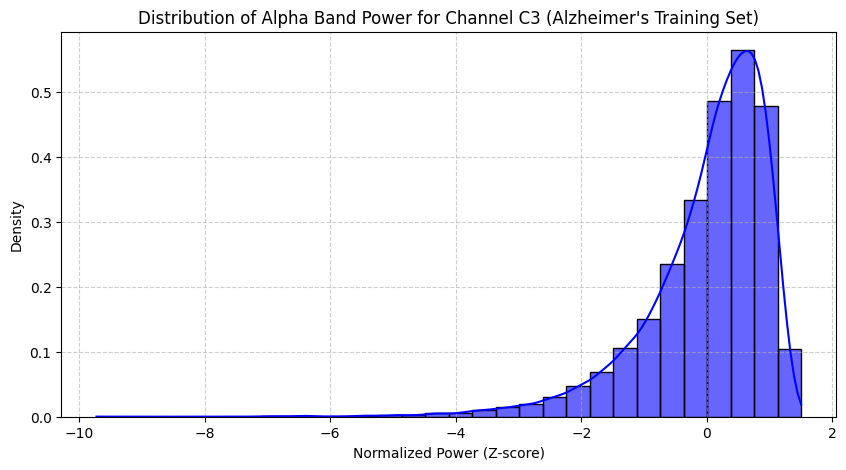

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract only the "Alpha" band for channel "C3"
alpha_c3_data = alz_train_scaled.loc[("Fp1", "Delta"), "Window Avg"]

# Ensure data is in list format
if isinstance(alpha_c3_data, list) or isinstance(alpha_c3_data, np.ndarray):
    plt.figure(figsize=(10, 5))

    # Plot histogram with density estimation (Kernel Density Estimation - KDE)
    sns.histplot(alpha_c3_data, bins=30, kde=True, color="blue", stat="density", alpha=0.6)

    plt.ylabel("Density")
    plt.xlabel("Normalized Power (Z-score)")
    plt.title("Distribution of Alpha Band Power for Channel C3 (Alzheimer's Training Set)")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()
else:
    print("⚠️ The extracted data is not in list format. Check if 'Window Avg' contains lists of values.")


# DOING PCA HERE ... 

In [52]:
print(alz_train_scaled)

                                                      Window Avg
Channel Band                                                    
C3      Alpha  [0.031959884488316485, 0.6722334495999984, -0....
        Beta   [-0.2065782892543617, 0.46547461952944186, -0....
        Delta  [0.18738769980971312, -0.522245661142559, 0.47...
        Theta  [-0.20886652930258243, 0.3201852935357545, -0....
C4      Alpha  [-0.20419613495194763, 0.0679730923025276, -0....
...                                                          ...
T5      Theta  [-0.5570195477923663, 0.7682539689952697, -0.3...
T6      Alpha  [-0.5164032184704169, -0.16405016127985148, -0...
        Beta   [-0.25082682389301864, 0.676427172294849, -0.3...
        Delta  [0.7758851935937338, -0.475675977969297, 0.688...
        Theta  [-0.8086614092191395, 0.690051382863, -0.49888...

[76 rows x 1 columns]


In [53]:
import numpy as np
import pandas as pd

# Flatten multi-index and create new column names
df_reshaped = alz_train_scaled["Window Avg"].apply(pd.Series)  # Expands lists into separate columns
# df_reshaped = control_train_scaled["Window Avg"].apply(pd.Series)  # Expands lists into separate columns
df_reshaped.index = df_reshaped.index.map(lambda x: f"{x[0]}_{x[1]}")  # Convert (Channel, Band) tuple into string
df_reshaped = df_reshaped.T  # Transpose so that rows = epochs and columns = features

# Convert to NumPy array (for PCA)
X_pca = df_reshaped.to_numpy()

# Print structure
print("PCA Input Shape:", X_pca.shape)  # (n_samples, n_features)
print("Feature Names:", df_reshaped.columns.tolist())  # Check feature names

PCA Input Shape: (17671, 76)
Feature Names: ['C3_Alpha', 'C3_Beta', 'C3_Delta', 'C3_Theta', 'C4_Alpha', 'C4_Beta', 'C4_Delta', 'C4_Theta', 'Cz_Alpha', 'Cz_Beta', 'Cz_Delta', 'Cz_Theta', 'F3_Alpha', 'F3_Beta', 'F3_Delta', 'F3_Theta', 'F4_Alpha', 'F4_Beta', 'F4_Delta', 'F4_Theta', 'F7_Alpha', 'F7_Beta', 'F7_Delta', 'F7_Theta', 'F8_Alpha', 'F8_Beta', 'F8_Delta', 'F8_Theta', 'Fp1_Alpha', 'Fp1_Beta', 'Fp1_Delta', 'Fp1_Theta', 'Fp2_Alpha', 'Fp2_Beta', 'Fp2_Delta', 'Fp2_Theta', 'Fz_Alpha', 'Fz_Beta', 'Fz_Delta', 'Fz_Theta', 'O1_Alpha', 'O1_Beta', 'O1_Delta', 'O1_Theta', 'O2_Alpha', 'O2_Beta', 'O2_Delta', 'O2_Theta', 'P3_Alpha', 'P3_Beta', 'P3_Delta', 'P3_Theta', 'P4_Alpha', 'P4_Beta', 'P4_Delta', 'P4_Theta', 'Pz_Alpha', 'Pz_Beta', 'Pz_Delta', 'Pz_Theta', 'T3_Alpha', 'T3_Beta', 'T3_Delta', 'T3_Theta', 'T4_Alpha', 'T4_Beta', 'T4_Delta', 'T4_Theta', 'T5_Alpha', 'T5_Beta', 'T5_Delta', 'T5_Theta', 'T6_Alpha', 'T6_Beta', 'T6_Delta', 'T6_Theta']


In [54]:
print("NaNs in X_train:", np.isnan(X_pca).sum())

NaNs in X_train: 0


In [55]:

# Apply PCA (reduce to 15 components for example)
pca = PCA(n_components=15)
X_pca_transformed = pca.fit_transform(X_pca)

# Print PCA results
print("PCA Output Shape:", X_pca_transformed.shape)  # (17830, 10)
print("Explained Variance Ratio:", pca.explained_variance_ratio_)


PCA Output Shape: (17671, 15)
Explained Variance Ratio: [0.58145502 0.10935743 0.09115262 0.03495501 0.02047026 0.01649166
 0.01393854 0.01136779 0.01021332 0.00923643 0.00709371 0.00661783
 0.00632889 0.00615099 0.00552516]


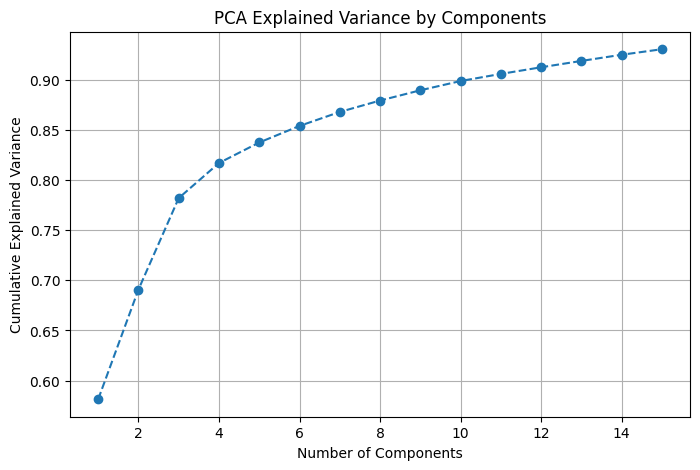

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, 16), np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance by Components')
plt.grid()
plt.show()

In [60]:
pca_df = pd.DataFrame(X_pca_transformed, columns=[f"PC{i+1}" for i in range(15)])

# Print first few rows
print(pca_df.head())

        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0  3.235288 -0.140389  0.414532 -0.172752 -0.288992 -0.641545  0.094197   
1 -3.408463  0.603120  1.071404  0.064901 -1.477227  0.378284 -0.033431   
2  3.619285  1.409659  0.329171  0.403133 -0.720832  0.403294 -0.394023   
3  2.012020  0.398855  1.215059 -0.367668 -0.124361 -0.612331 -0.300848   
4 -5.720170  3.159392 -0.184575  1.151203 -2.027080  1.302038  0.336473   

        PC8       PC9      PC10      PC11      PC12      PC13      PC14  \
0 -0.104829 -0.301409  0.010597  0.450237 -0.015998  0.089891  0.065084   
1  0.172702 -0.589884  0.305693  0.575885  0.032753  0.464423 -0.378732   
2  0.478346 -0.759896  0.149357  0.292031 -0.165038 -0.296408  0.189590   
3 -0.386825 -0.752161  0.249590  0.364184  0.039692 -0.068736  0.080743   
4 -0.735131 -0.954039  0.158503  0.721081  0.227369  0.252380  0.150680   

       PC15  
0  0.219185  
1 -0.298119  
2  0.107632  
3 -0.128028  
4  0.074688  


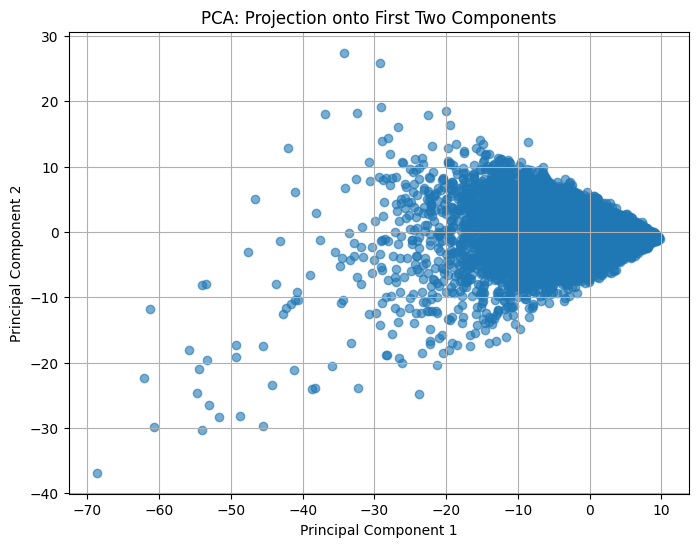

In [61]:
plt.figure(figsize=(8,6))
plt.scatter(pca_df["PC1"], pca_df["PC2"], alpha=0.6)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA: Projection onto First Two Components")
plt.grid(True)
plt.show()


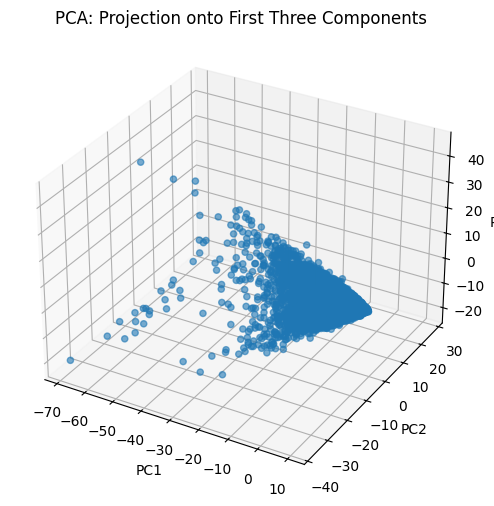

In [62]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pca_df["PC1"], pca_df["PC2"], pca_df["PC3"], alpha=0.6)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("PCA: Projection onto First Three Components")
plt.show()


# Doing ML portion now 

# Preprocessing

In [63]:
def multi_index(data_scaled):
    """
    data_scaled is a DataFrame where:
      - The index is a MultiIndex of (Channel, Band)
      - 'Window Avg' column has the list of average values for each epoch
    This function expands those average values into separate columns.
    Then transposes, so rows become epochs and columns become features.
    """
    df_reshaped = data_scaled["Window Avg"].apply(pd.Series)  # Expand lists into columns
    # Flatten multi-index: if the index is (Channel, Band), turn it into "Channel_Band"
    df_reshaped.index = df_reshaped.index.map(lambda x: f"{x[0]}_{x[1]}")
    df_reshaped = df_reshaped.T  # transpose so rows=epochs, columns=features
    return df_reshaped

X_alz_train = multi_index(alz_train_scaled)
X_alz_test = multi_index(alz_test_scaled)
X_control_train = multi_index(control_train_scaled)
X_control_test = multi_index(control_test_scaled)


In [64]:
y_alz_train = np.ones(X_alz_train.shape[0], dtype=int)
y_alz_test = np.ones(X_alz_test.shape[0], dtype=int)
y_control_train = np.zeros(X_control_train.shape[0], dtype=int)
y_control_test = np.zeros(X_control_test.shape[0], dtype=int)


In [65]:
# Combine features
X_train = pd.concat([X_alz_train, X_control_train], ignore_index=True)
X_test  = pd.concat([X_alz_test,  X_control_test ], ignore_index=True)

# Combine labels
y_train = np.concatenate([y_alz_train, y_control_train])
y_test  = np.concatenate([y_alz_test,  y_control_test])


In [66]:
X_train = X_train.to_numpy()
X_test = X_test.to_numpy()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (32013, 76)
y_train shape: (32013,)
X_test shape: (3384, 76)
y_test shape: (3384,)


# PCA

In [67]:
pca = PCA(n_components=10)
X_train_pca_transformed = pca.fit_transform(X_train)  # shape (N_train, 10)
X_test_pca_transformed  = pca.transform(X_test)       # shape (N_test, 10)

In [68]:
knn = KNeighborsClassifier(n_neighbors=150)
knn.fit(X_train_pca_transformed, y_train)

y_pred = knn.predict(X_test_pca_transformed)
acc = accuracy_score(y_test, y_pred)
print(f"KNN accuracy: {acc:.4f}")

KNN accuracy: 0.7379


In [69]:
report = classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1'])

# Print the classification report
print(report)

              precision    recall  f1-score   support

     Class 0       0.84      0.58      0.69      1687
     Class 1       0.68      0.89      0.77      1697

    accuracy                           0.74      3384
   macro avg       0.76      0.74      0.73      3384
weighted avg       0.76      0.74      0.73      3384



# SVM 

In [70]:
svm = SVC(kernel='rbf', C=1.0)  # You can change the kernel to 'linear', 'poly', or 'sigmoid'

# Train the SVM model
svm.fit(X_train_pca_transformed, y_train)

# Predict using the trained SVM model
y_pred_svm = svm.predict(X_test_pca_transformed)

# Compute accuracy
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {acc_svm:.4f}")

# Generate and print classification report (Precision, Recall, F1 Score)
report_svm = classification_report(y_test, y_pred_svm, target_names=['Class 0', 'Class 1'])
print(report_svm)

SVM Accuracy: 0.7429
              precision    recall  f1-score   support

     Class 0       0.89      0.56      0.68      1687
     Class 1       0.68      0.93      0.78      1697

    accuracy                           0.74      3384
   macro avg       0.78      0.74      0.73      3384
weighted avg       0.78      0.74      0.73      3384



In [34]:
ridge = RidgeClassifier(alpha=1.0)  # alpha is the regularization strength

# Train the Ridge model
ridge.fit(X_train_pca_transformed, y_train)

# Predict using the trained Ridge model
y_pred_ridge = ridge.predict(X_test_pca_transformed)

# Compute accuracy
acc_ridge = accuracy_score(y_test, y_pred_ridge)
print(f"Ridge Regression Accuracy: {acc_ridge:.4f}")

# Generate and print classification report (Precision, Recall, F1 Score)
report_ridge = classification_report(y_test, y_pred_ridge, target_names=['Class 0', 'Class 1'])
print(report_ridge)

Ridge Regression Accuracy: 0.5037
              precision    recall  f1-score   support

     Class 0       0.00      0.00      0.00      1691
     Class 1       0.50      1.00      0.67      1716

    accuracy                           0.50      3407
   macro avg       0.25      0.50      0.33      3407
weighted avg       0.25      0.50      0.34      3407



/Users/admin/neuro-venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/admin/neuro-venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/admin/neuro-venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [71]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)  # You can adjust n_estimators

# Train the Random Forest model
rf.fit(X_train_pca_transformed, y_train)

# Predict using the trained Random Forest model
y_pred_rf = rf.predict(X_test_pca_transformed)

# Compute accuracy
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {acc_rf:.4f}")

# Generate and print classification report (Precision, Recall, F1 Score)
report_rf = classification_report(y_test, y_pred_rf, target_names=['Class 0', 'Class 1'])
print(report_rf)

Random Forest Accuracy: 0.7243
              precision    recall  f1-score   support

     Class 0       0.79      0.61      0.69      1687
     Class 1       0.68      0.84      0.75      1697

    accuracy                           0.72      3384
   macro avg       0.74      0.72      0.72      3384
weighted avg       0.74      0.72      0.72      3384



In [72]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Initialize the Logistic Regression model
log_reg = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42) 

# Train the Logistic Regression model
log_reg.fit(X_train_pca_transformed, y_train)

# Predict using the trained Logistic Regression model
y_pred_log_reg = log_reg.predict(X_test_pca_transformed)

# Compute accuracy
acc_log_reg = accuracy_score(y_test, y_pred_log_reg)
print(f"Logistic Regression Accuracy: {acc_log_reg:.4f}")

# Generate and print classification report (Precision, Recall, F1 Score)
report_log_reg = classification_report(y_test, y_pred_log_reg, target_names=['Class 0', 'Class 1'])
print(report_log_reg)

Logistic Regression Accuracy: 0.5015
              precision    recall  f1-score   support

     Class 0       0.00      0.00      0.00      1687
     Class 1       0.50      1.00      0.67      1697

    accuracy                           0.50      3384
   macro avg       0.25      0.50      0.33      3384
weighted avg       0.25      0.50      0.33      3384



/Users/admin/neuro-venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/admin/neuro-venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/admin/neuro-venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [73]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize Gradient Boosting Classifier
gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

# Train the model
gbc.fit(X_train_pca_transformed, y_train)

# Make predictions
y_pred = gbc.predict(X_test_pca_transformed)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Gradient Boosting Model Accuracy: {accuracy * 100:.2f}%")

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Gradient Boosting Model Accuracy: 66.16%

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.51      0.60      1687
           1       0.62      0.81      0.71      1697

    accuracy                           0.66      3384
   macro avg       0.68      0.66      0.65      3384
weighted avg       0.68      0.66      0.65      3384



# previous attempt below

In [292]:
# Flatten multi-index and create new column names
def multi_index(data_scaled):
    df_reshaped = data_scaled["Window Avg"].apply(pd.Series)  # Expands lists into separate columns
    df_reshaped.index = df_reshaped.index.map(lambda x: f"{x[0]}_{x[1]}")  # Convert (Channel, Band) tuple into string
    df_reshaped = df_reshaped.T  # Transpose so that rows = epochs and columns = features
    return df_reshaped

# Convert to NumPy array (for PCA)
X_train = multi_index(alz_train_scaled).to_numpy()
X_test = multi_index(alz_test_scaled).to_numpy()
y_train = multi_index(control_train_scaled).to_numpy()
y_test = multi_index(control_test_scaled).to_numpy()

# y_alz_train = np.ones(X_alz_train.shape[0], dtype=int)
# y_alz_test = np.ones(X_alz_test.shape[0], dtype=int)
# y_control_train = np.zeros(X_control_train.shape[0], dtype=int)
# y_control_test = np.zeros(X_control_test.shape[0], dtype=int)

NameError: name 'X_alz_train' is not defined

In [283]:
print("NaNs in X_train:", np.isnan(X_train).sum())
print("NaNs in X_test:", np.isnan(X_test).sum())
print("NaNs in y_train:", np.isnan(y_train).sum())
print("NaNs in y_test:", np.isnan(y_test).sum())

NaNs in X_train: 0
NaNs in X_test: 0
NaNs in y_train: 0
NaNs in y_test: 0


In [284]:
pca = PCA(n_components=10)
X_train_pca_transformed = pca.fit_transform(X_train)
X_test_pca_transformed = pca.transform(X_test)
y_train_pca_transformed = pca.transform(y_train)
y_test_pca_transformed = pca.transform(y_test)

In [285]:
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Cumulative explained variance:", pca.explained_variance_ratio_.cumsum()[-1])


Explained variance ratio: [0.58326401 0.10737446 0.08955702 0.03637641 0.02190768 0.01653056
 0.01563926 0.01193116 0.01003805 0.00953225]
Cumulative explained variance: 0.9021508680955017


In [291]:
#make the data the same size 
print(len(X_train_pca_transformed))
print(len(y_train_pca_transformed))
max_train_size = min(len(X_train_pca_transformed), len(y_test_pca_transformed))
print(max_train_size)
X_train_pca_transformed = X_train_pca_transformed[:max_train_size]
y_train_pca_transformed = y_train_pca_transformed[:max_train_size]
print(len(X_train_pca_transformed))
print(len(y_train_pca_transformed))

1691
1691
1691
1691
1691


In [342]:

# --- KNN ---
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_pca_transformed, y_train_pca_transformed)
y_pred = knn.predict(X_test_pca_transformed)

acc = accuracy_score(y_test, y_pred)
print(f"KNN accuracy with 10 PCA components: {acc:.4f}")

ValueError: Found input variables with inconsistent numbers of samples: [32386, 1691]

In [242]:
alz_train_df["Label"] = 1
alz_test_df["Label"] = 1
control_train_df["Label"] = 0
control_test_df["Label"] = 0

# Quick checks
print("alz_train_df shape:", alz_train_df.shape)
print("alz_test_df shape:", alz_test_df.shape)
print("control_train_df shape:", control_train_df.shape)
print("control_test_df shape:", control_test_df.shape)

alz_train_df shape: (2508, 2)
alz_test_df shape: (228, 2)
control_train_df shape: (1976, 2)
control_test_df shape: (228, 2)


In [243]:
# Combine the training data
train_df = pd.concat([alz_train_df, control_train_df], ignore_index=True)

# Combine the testing data
test_df = pd.concat([alz_test_df, control_test_df], ignore_index=True)

# Check shapes again
print("Combined train_df shape:", train_df.shape)
print("Combined test_df shape:", test_df.shape)

Combined train_df shape: (4484, 2)
Combined test_df shape: (456, 2)


In [251]:
X_train_fixed = np.vstack(X_train[:, 0])
X_test_fixed  = np.vstack(X_test[:, 0])
y_train_fixed = np.vstack(X_train[:, 0])
y_test_fixed  = np.vstack(X_test[:, 0])

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 398 and the array at index 76 has size 527

In [244]:
# We assume all columns except 'Label' are features
feature_cols = [col for col in train_df.columns if col != "Label"]

# Separate X (features) and y (label)
X_train = train_df[feature_cols].values
y_train = train_df["Label"].values

X_test = test_df[feature_cols].values
y_test = test_df["Label"].values

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4484, 1)
y_train shape: (4484,)
X_test shape: (456, 1)
y_test shape: (456,)


In [250]:
print(X_train[0][0][0])

0.08257892642542035


In [245]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ValueError: setting an array element with a sequence.

In [236]:
alz_train_df["Label"] = 1
alz_test_df["Label"] = 1
control_train_df["Label"] = 0
control_test_df["Label"] = 0

train_df = pd.concat([alz_train_df, control_train_df])
test_df = pd.concat([alz_test_df, control_test_df])

In [240]:

# Check for NaNs in training and test data
print("NaNs in X_train:", np.isnan().sum())
print("NaNs in X_test:", np.isnan(X_test).sum())


TypeError: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

In [233]:
# Flatten multi-index and create new column names
df_reshaped_train = train_df["Window Avg"].apply(pd.Series)  # Expands lists into separate columns
df_reshaped_test = test_df["Window Avg"].apply(pd.Series)  # Expands lists into separate columns

# Convert index from (Subject, Channel, Band) → "Channel_Band"
df_reshaped_train.index = df_reshaped_train.index.map(lambda x: f"{x[0]}_{x[1]}")
df_reshaped_test.index = df_reshaped_test.index.map(lambda x: f"{x[0]}_{x[1]}")

# Transpose so that rows = epochs and columns = features
df_reshaped_train = df_reshaped_train.T
df_reshaped_test = df_reshaped_test.T

# Extract Labels (0 = Control, 1 = Alzheimer's)
train_labels = train_df["Label"].values
test_labels = test_df["Label"].values

# Convert to NumPy array for PCA
X_train = df_reshaped_train.to_numpy()
X_test = df_reshaped_test.to_numpy()


In [234]:
# Apply PCA (keeping 15 components)
pca = PCA(n_components=10)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Print PCA Output Shape
print("Train PCA Shape:", X_train_pca.shape)
print("Test PCA Shape:", X_test_pca.shape)


ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [232]:
# Initialize KNN classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_pca, train_labels)

# Make predictions
y_pred = knn.predict(X_test_pca)

# Compute accuracy
accuracy = accuracy_score(test_labels, y_pred)
print(f"KNN Model Accuracy: {accuracy * 100:.2f}%")

# Print detailed classification report
print("\nClassification Report:")
print(classification_report(test_labels, y_pred))


NameError: name 'X_train_pca' is not defined

## other stuff below 

In [101]:

# #**highly skeptical of this **
# from sklearn.preprocessing import StandardScaler
# import numpy as np

# # Function to normalize train & test data per band using training parameters
# def normalize_band(train_df, test_df):
#     train_df = train_df.copy()
#     test_df = test_df.copy()

#     # Convert "Window Avg" lists to NumPy arrays
#     train_df["Window Avg"] = train_df["Window Avg"].apply(lambda x: np.array(x) if isinstance(x, list) else x)
#     test_df["Window Avg"] = test_df["Window Avg"].apply(lambda x: np.array(x) if isinstance(x, list) else x)

#     # Fit scaler separately for each row (instead of on the whole dataset)
#     def scale_list(scaler, x):
#         x = x.reshape(-1, 1)  # Ensure correct shape for StandardScaler
#         return scaler.fit_transform(x).flatten()  # Fit & transform per row

#     train_df["Window Avg"] = train_df["Window Avg"].apply(lambda x: scale_list(StandardScaler(), x))
#     test_df["Window Avg"] = test_df["Window Avg"].apply(lambda x: scale_list(StandardScaler(), x))

#     return train_df, test_df

# # Apply function to each Band separately for Alzheimer's group
# alz_train_scaled, alz_test_scaled = zip(*alz_train_df_combined.groupby("Band", group_keys=False).apply(
#     lambda g: normalize_band(g, alz_test_df_combined.loc[g.index])
# ).values)

# # Apply function to each Band separately for Control group
# control_train_scaled, control_test_scaled = zip(*control_train_df_combined.groupby("Band", group_keys=False).apply(
#     lambda g: normalize_band(g, control_test_df_combined.loc[g.index])
# ).values)


# print(alz_train_scaled)
# print(alz_test_scaled)
# print(control_train_scaled)
# print(control_test_scaled)

# Print first few rows
#print(alz_train_scaled.head())
#print(alz_test_scaled.head())
#print(control_train_scaled.head())
#print(control_test_scaled.head())


(                                                      Window Avg
Channel Band                                                    
C3      Alpha  [-0.04686726223962491, -0.04661130577141434, -...
C4      Alpha  [-0.04760613651720091, -0.04892202669828345, -...
Cz      Alpha  [-0.04817863495359442, -0.047677641739982846, ...
F3      Alpha  [-0.04896373618934346, -0.04827272701695156, -...
F4      Alpha  [-0.04836769435505512, -0.049180375552753515, ...
F7      Alpha  [-0.050449410580874134, -0.05032048879978084, ...
F8      Alpha  [-0.04382649018252775, -0.044773102316942016, ...
Fp1     Alpha  [-0.04297289274833778, -0.04886054118973562, -...
Fp2     Alpha  [-0.04346906694177611, -0.04848360613177401, -...
Fz      Alpha  [-0.04956024009811652, -0.04948518192795945, -...
O1      Alpha  [-0.03504835336925742, -0.035280954786490216, ...
O2      Alpha  [-0.0479543003007958, -0.04817912603633828, -0...
P3      Alpha  [-0.05223056380676035, -0.05213337976278488, -...
P4      Alpha  [-0.04339

In [83]:
# Merge all Window Avg values for each (Channel, Band) into a single list
alz_combined = alz_combined.groupby(["Channel", "Band"])["Window Avg"].sum()
control_combined = control_combined.groupby(["Channel", "Band"])["Window Avg"].sum()

# Convert back to DataFrame (optional)
alz_combined = alz_combined.to_frame()
control_combined = control_combined.to_frame()

# Print results
print(alz_combined.head())
print(control_combined.head())

                                                      Window Avg
Channel Band                                                    
C3      Alpha  [1.1952646428442352e-09, 1.243587730757724e-09...
        Beta   [3.440334682399176e-10, 3.3680858853976883e-10...
        Delta  [1.343193533659429e-07, 2.6631502953716043e-07...
        Theta  [4.612288195341671e-09, 5.628089980277074e-09,...
C4      Alpha  [1.15823465152569e-09, 9.120024993533683e-10, ...
                                                      Window Avg
Channel Band                                                    
C3      Alpha  [2.1527058139996137e-09, 1.899380401941476e-09...
        Beta   [3.2686312023167596e-10, 2.953228713639168e-10...
        Delta  [1.289780396177284e-07, 1.1712672841658123e-07...
        Theta  [3.621755806117966e-09, 4.970567975602138e-09,...
C4      Alpha  [2.054821034173802e-09, 2.2006669884943113e-09...


In [94]:
#checking the state
print(alz_combined) 
print(control_combined) 

print(type(control_combined.loc[('Fp1', 'Delta'), "Window Avg"]))
print(type(control_combined.loc[('Fp1', 'Delta'), "Window Avg"][0]))
# print((control_combined.loc[('Fp1', 'Delta'), "Window Avg"]))
# print(alz_combined.loc[('sub-001', 'Fp1', 'Delta'), "Window Avg"][0])

                                                      Window Avg
Channel Band                                                    
C3      Alpha  [1.1952646428442352e-09, 1.243587730757724e-09...
        Beta   [3.440334682399176e-10, 3.3680858853976883e-10...
        Delta  [1.343193533659429e-07, 2.6631502953716043e-07...
        Theta  [4.612288195341671e-09, 5.628089980277074e-09,...
C4      Alpha  [1.15823465152569e-09, 9.120024993533683e-10, ...
...                                                          ...
T5      Theta  [4.5882640670242895e-09, 6.594935864443824e-09...
T6      Alpha  [1.3621702809217911e-09, 1.6064003784801627e-0...
        Beta   [3.841039340557157e-10, 4.743714072500563e-10,...
        Delta  [1.7175379583888522e-07, 2.6736669150319846e-0...
        Theta  [3.6770714985585547e-09, 5.717439153997815e-09...

[76 rows x 1 columns]
                                                      Window Avg
Channel Band                                                    
C3

In [95]:
#This ensures everything is a single item list or array, shouldn't be needed but its a safety net
alz_combined["Window Avg"] = alz_combined["Window Avg"].apply(lambda x: float(x) if isinstance(x, (list, np.ndarray)) and len(x) == 1 else x)
control_combined["Window Avg"] = control_combined["Window Avg"].apply(lambda x: float(x) if isinstance(x, (list, np.ndarray)) and len(x) == 1 else x)

print(alz_combined)
print(control_combined) #check that all the channels are here , looks like they got moved

                                                      Window Avg
Channel Band                                                    
C3      Alpha  [1.1952646428442352e-09, 1.243587730757724e-09...
        Beta   [3.440334682399176e-10, 3.3680858853976883e-10...
        Delta  [1.343193533659429e-07, 2.6631502953716043e-07...
        Theta  [4.612288195341671e-09, 5.628089980277074e-09,...
C4      Alpha  [1.15823465152569e-09, 9.120024993533683e-10, ...
...                                                          ...
T5      Theta  [4.5882640670242895e-09, 6.594935864443824e-09...
T6      Alpha  [1.3621702809217911e-09, 1.6064003784801627e-0...
        Beta   [3.841039340557157e-10, 4.743714072500563e-10,...
        Delta  [1.7175379583888522e-07, 2.6736669150319846e-0...
        Theta  [3.6770714985585547e-09, 5.717439153997815e-09...

[76 rows x 1 columns]
                                                      Window Avg
Channel Band                                                    
C3

# Now we are normalizing and applying PCA

In [103]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Function to apply StandardScaler per band
def normalize_band(df):
    df = df.copy()  # Avoid modifying original dataframe
    scaler = StandardScaler()
    
    # Convert "Window Avg" lists to NumPy arrays
    df["Window Avg"] = df["Window Avg"].apply(lambda x: np.array(x) if isinstance(x, list) else x)
    
    # Stack arrays into a 2D matrix
    X = np.vstack(df["Window Avg"].values)  
    
    # Scale values
    X_scaled = scaler.fit_transform(X)
    
    # Store back in DataFrame
    df["Window Avg"] = list(X_scaled)
    
    return df

# Apply function to each Band separately
alz_scaled = alz_combined.groupby("Band", group_keys=False).apply(normalize_band)
control_scaled = control_combined.groupby("Band", group_keys=False).apply(normalize_band)

# Print first few rows
print(alz_scaled.head())
print(control_scaled.head())


[[1.19526464e-09 1.24358773e-09 1.14422465e-09 ... 1.04039027e-09
  1.14957071e-09 8.72237207e-10]
 [1.15823465e-09 9.12002499e-10 1.02765620e-09 ... 1.08116609e-09
  1.14999732e-09 7.75782900e-10]
 [1.12811121e-09 1.22159138e-09 1.11538457e-09 ... 8.90449012e-10
  9.52819757e-10 7.96263853e-10]
 ...
 [1.21050687e-09 1.26062901e-09 1.13313572e-09 ... 2.84172598e-09
  2.82322287e-09 1.35255805e-09]
 [1.73123748e-09 1.78767216e-09 1.38269672e-09 ... 1.88259031e-09
  2.59158197e-09 1.76563586e-09]
 [1.36217028e-09 1.60640038e-09 1.56427322e-09 ... 2.17809250e-09
  1.49192671e-09 1.02444950e-09]]
[[3.44033468e-10 3.36808589e-10 3.28769207e-10 ... 2.58424310e-10
  3.84902130e-10 3.59259125e-10]
 [3.08823832e-10 3.68182253e-10 3.05810501e-10 ... 3.58707838e-10
  4.38736412e-10 3.98179065e-10]
 [3.20589999e-10 3.53352485e-10 3.02441922e-10 ... 3.13185314e-10
  3.86040425e-10 4.08682536e-10]
 ...
 [5.21389792e-10 4.87712033e-10 3.67222124e-10 ... 6.76504075e-10
  7.55545687e-10 7.50272765e-10]